# Experiment 4 · MNIST Digit Recognition

A `784 -> hidden (ReLU) -> 10 (softmax)` network built with `numpy_nn` is trained on the 60,000
MNIST training images and scored on the 10,000 test images. This experiment tunes the hyper-parameters,
studies what happens when training runs far too long, and probes the trained network with inputs
that are not digits at all.

## Reading the data

MNIST files use the IDX format: a big-endian header followed by raw unsigned bytes.
Label files have an 8-byte header (magic number, count); image files have a 16-byte
header (magic number, count, rows, cols). We skip the header and read the rest as `uint8`.

In [1]:
import sys
from pathlib import Path

import numpy as np

# the repository root is the first folder above this notebook that holds pyproject.toml
REPO_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

DATA_DIR = REPO_ROOT / "data" / "mnist"
MODEL_DIR = REPO_ROOT / "models"
BEST_MODEL_PATH = MODEL_DIR / "mnist_best.npz"
OVERTRAINED_MODEL_PATH = MODEL_DIR / "mnist_overtrained.npz"
IMAGE_SIZE = 28

def read_labels(filename):
    data = (DATA_DIR / filename).read_bytes()
    return np.frombuffer(data, dtype=np.uint8, offset=8)

def read_images(filename):
    data = (DATA_DIR / filename).read_bytes()
    pixels = np.frombuffer(data, dtype=np.uint8, offset=16)
    return pixels.reshape(-1, IMAGE_SIZE, IMAGE_SIZE)

In [2]:
train_images = read_images("train-images-idx3-ubyte")
train_labels = read_labels("train-labels-idx1-ubyte")
test_images = read_images("t10k-images-idx3-ubyte")
test_labels = read_labels("t10k-labels-idx1-ubyte")

print("train:", train_images.shape, train_labels.shape)
print("test: ", test_images.shape, test_labels.shape)
print("labels:", np.unique(train_labels))
print("pixels:", train_images.min(), "to", train_images.max())
print("first labels:", train_labels[:10])

train: (60000, 28, 28) (60000,)
test:  (10000, 28, 28) (10000,)
labels: [0 1 2 3 4 5 6 7 8 9]
pixels: 0 to 255
first labels: [5 0 4 1 9 2 1 3 1 4]


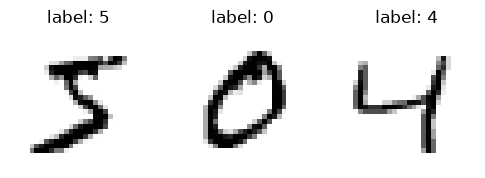

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(6, 2.5))
for i, ax in enumerate(axes):
    ax.imshow(train_images[i], cmap="gray_r")
    ax.set_title(f"label: {train_labels[i]}")
    ax.axis("off")
plt.show()

### Curating the data

The network expects one row per example, so each 28×28 image is flattened to 784 inputs
and scaled from 0–255 down to 0–1. Each label becomes a one-hot vector of length 10 to match
the 10 softmax outputs (e.g. `3` → `[0,0,0,1,0,0,0,0,0,0]`).

In [4]:
NUM_CLASSES = 10


# Normalizing inputs
def to_inputs(images):
    return images.reshape(len(images), -1) / 255.0

# For softmax targets
def to_one_hot(labels):
    return np.eye(NUM_CLASSES)[labels]


train_inputs, train_targets = to_inputs(train_images), to_one_hot(train_labels)
test_inputs, test_targets = to_inputs(test_images), to_one_hot(test_labels)

print("inputs: ", train_inputs.shape, train_inputs.min(), "to", train_inputs.max())
print("targets:", train_targets.shape)
print("label", train_labels[0], "->", train_targets[0])

inputs:  (60000, 784) 0.0 to 1.0
targets: (60000, 10)
label 5 -> [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Hyper-parameter study

Network: `784 inputs -> hidden (ReLU) -> 10 outputs (softmax)`, trained with cross-entropy on
shuffled mini-batches. Training stops at the first epoch that reaches the accuracy target: **≥ 99% training
accuracy** and **≥ 97% test accuracy** (at most 3% wrong).

`build_network` takes the hidden size and the range the initial weights are drawn from, so the
same helper covers every study in (1)–(4).

In [5]:
from numpy_nn import ACTIVATIONS, COSTS, Layer, Network, random_weights, zero_bias
from numpy_trainer import DataLoader, Trainer, plot_history

INPUT_SIZE = IMAGE_SIZE * IMAGE_SIZE
BATCH_SIZE = 32
TARGET_ACCURACY = 0.99
TARGET_TEST_ACCURACY = 0.97


def build_network(hidden_size, weight_range=(-0.05, 0.05), seed=0):
    np.random.seed(seed)
    low, high = weight_range

    hidden_layer = Layer.build(
        input_size=INPUT_SIZE, output_size=hidden_size,
        weight=random_weights(INPUT_SIZE, hidden_size, low, high),
        bias=zero_bias(hidden_size),
        activation=ACTIVATIONS.RELU
    )
    output_layer = Layer.build(
        input_size=hidden_size, output_size=NUM_CLASSES,
        weight=random_weights(hidden_size, NUM_CLASSES, low, high),
        bias=zero_bias(NUM_CLASSES),
        activation=ACTIVATIONS.SOFTMAX
    )

    return Network(hidden_layer, output_layer)


# the target: at least 99% of the training images and 97% of the test images classified correctly
def reached_target(result):
    return result.accuracy >= TARGET_ACCURACY and result.validation_accuracy >= TARGET_TEST_ACCURACY


# the test set is passed as validation data: it is evaluated every epoch but never trained on
def train_network(network, learning_rate, train_x=train_inputs, test_x=test_inputs, max_epochs=20, print_interval=1):
    trainer = Trainer(network, cost=COSTS.CROSS_ENTROPY, learning_rate=learning_rate)
    trainer.train(
        DataLoader(train_x, train_targets, batch_size=BATCH_SIZE, shuffle=True),
        epochs=max_epochs,
        validation=(test_x, test_targets),
        print_interval=print_interval,
        stop_when=reached_target
    )
    return trainer


# number of wrongly predicted test images; accuracy is correct / total, so this is exact
def misclassified(test_accuracy):
    return round((1 - test_accuracy) * len(test_targets))


# one line per experiment: epochs used, the final train/test accuracy and how many test images are wrong
def summarize(trainer):
    last = trainer.history[-1]
    return (
        f"epochs: {last.epoch:>2} | "
        f"train: {last.accuracy:.2%} | "
        f"test: {last.validation_accuracy:.2%} | "
        f"wrong: {misclassified(last.validation_accuracy):>4}/{len(test_targets)}"
    )

### Best set-up

A small sweep (hidden size 100/300, learning rate 0.3/0.5, batch size 16/32/64) found this
combination reaches the target in the fewest epochs: **300 hidden units, weights in ±0.05,
learning rate 0.3**.

In [ ]:
BEST_HIDDEN_SIZE = 300
BEST_WEIGHT_RANGE = (-0.05, 0.05)
BEST_LEARNING_RATE = 0.3

best_network = build_network(BEST_HIDDEN_SIZE, BEST_WEIGHT_RANGE)
best_trainer = train_network(best_network, BEST_LEARNING_RATE)

### (1) Size of the hidden layer

One size from each range — less than 50 (25), 50–500 (256), larger than 500 (1024) — with
everything else kept at the best set-up.

In [ ]:
HIDDEN_SIZES = [25, 256, 1024]

hidden_size_trainers = {}
for hidden_size in HIDDEN_SIZES:
    print(f"\n--- hidden size {hidden_size} ---")
    network = build_network(hidden_size, BEST_WEIGHT_RANGE)
    hidden_size_trainers[hidden_size] = train_network(network, BEST_LEARNING_RATE)

print()
for hidden_size, trainer in hidden_size_trainers.items():
    print(f"hidden {hidden_size:>4} | {summarize(trainer)}")

### (2) Initial random weights

The starting weights of both layers are drawn from one of three ranges — all positive, all
negative, or both — with everything else kept at the best set-up.

In [ ]:
WEIGHT_RANGES = {
    "positive": (0.0, 0.1),
    "negative": (-0.1, 0.0),
    "both": (-0.5, 0.5),
}

weight_range_trainers = {}
for name, weight_range in WEIGHT_RANGES.items():
    print(f"\n--- {name} weights {weight_range} ---")
    network = build_network(BEST_HIDDEN_SIZE, weight_range)
    weight_range_trainers[name] = train_network(network, BEST_LEARNING_RATE)

print()
for name, trainer in weight_range_trainers.items():
    print(f"{name:>8} | {summarize(trainer)}")

### (3) Learning rate

The learning rate is set to 0.3, 0.5 or 0.7, with everything else kept at the best set-up.

In [ ]:
LEARNING_RATES = {
    "lr: 0.3": 0.3,
    "lr: 0.5": 0.5,
    "lr: 0.7": 0.7
}


learning_rate_trainers = {}
for name, lr in LEARNING_RATES.items():
    print(f"\n--- Learning Rate {lr} ---")
    network = build_network(BEST_HIDDEN_SIZE, BEST_WEIGHT_RANGE)
    learning_rate_trainers[name] = train_network(network, lr)

print()
for lr_name, trainer in learning_rate_trainers.items():
    print(f"{lr_name:>8} | {summarize(trainer)}")

### (4) Additional curation — removing the grey pixels

Each pixel keeps only one bit of precision: at or above the halfway grey level (128) it becomes 1
(ink), below it becomes 0 (background). The anti-aliased grey edges disappear and every image is
pure black and white. The test images are curated the same way, and everything else is kept at
the best set-up (still trained with categorical cross-entropy).

In [ ]:
BINARY_THRESHOLD = 128


def to_binary_inputs(images):
    return (images.reshape(len(images), -1) >= BINARY_THRESHOLD).astype(float)


binary_train_inputs = to_binary_inputs(train_images)
binary_test_inputs = to_binary_inputs(test_images)

# the same first three images, before (grey) and after (binary) curation
fig, axes = plt.subplots(2, 3, figsize=(6, 4.5))
for i in range(3):
    axes[0, i].imshow(train_images[i], cmap="gray_r")
    axes[0, i].set_title(f"grey: {train_labels[i]}")
    axes[1, i].imshow(binary_train_inputs[i].reshape(IMAGE_SIZE, IMAGE_SIZE), cmap="gray_r")
    axes[1, i].set_title(f"binary: {train_labels[i]}")
for ax in axes.flat:
    ax.axis("off")
plt.show()

network = build_network(BEST_HIDDEN_SIZE, BEST_WEIGHT_RANGE)
binary_trainer = train_network(network, BEST_LEARNING_RATE, binary_train_inputs, binary_test_inputs)

print()
print(f"  grey | {summarize(best_trainer)}")
print(f"binary | {summarize(binary_trainer)}")

#### Averaging over seeds

A single run differs by only a few dozen test images between grey and binary, which is close
to the run-to-run noise. Both inputs are therefore trained with the same 5 seeds (the seed fixes
the initial weights and the shuffle order), and the averages are compared.

In [ ]:
SEEDS = [0, 1, 2, 3, 4]
CURATIONS = {
    "grey": (train_inputs, test_inputs),
    "binary": (binary_train_inputs, binary_test_inputs),
}

# (epochs, train accuracy, test accuracy) of every seed, per curation
seed_results = {name: [] for name in CURATIONS}
for seed in SEEDS:
    for name, (train_x, test_x) in CURATIONS.items():
        network = build_network(BEST_HIDDEN_SIZE, BEST_WEIGHT_RANGE, seed=seed)
        # the per-epoch log of all 10 runs is hidden; only each run's final numbers are shown
        trainer = train_network(network, BEST_LEARNING_RATE, train_x, test_x, print_interval=0)

        last = trainer.history[-1]
        seed_results[name].append((last.epoch, last.accuracy, last.validation_accuracy))
        print(f"seed {seed} | {name:>6} | {summarize(trainer)}")

print()
for name, results in seed_results.items():
    epochs, train_accuracy, test_accuracy = np.array(results).T
    print(
        f"{name:>6} average | epochs: {epochs.mean():.1f} | "
        f"train: {train_accuracy.mean():.2%} ± {train_accuracy.std():.2%} | "
        f"test: {test_accuracy.mean():.2%} ± {test_accuracy.std():.2%}"
    )

**Results over 5 seeds** (training stops at the first epoch with ≥ 99% train and ≥ 97% test accuracy):

| Seed | Grey epochs | Grey train | Grey test | Binary epochs | Binary train | Binary test |
|---|---|---|---|---|---|---|
| 0 | 5 | 99.01% | 97.84% | 5 | 99.25% | 97.62% |
| 1 | 6 | 99.25% | 97.93% | 5 | 99.23% | 97.77% |
| 2 | 5 | 99.01% | 97.97% | 5 | 99.33% | 97.44% |
| 3 | 6 | 99.20% | 98.30% | 5 | 99.19% | 97.72% |
| 4 | 6 | 99.23% | 97.99% | 5 | 99.25% | 97.63% |
| **Average** | **5.6** | **99.14% ± 0.11%** | **98.01% ± 0.16%** | **5.0** | **99.25% ± 0.04%** | **97.64% ± 0.11%** |

Removing the grey pixels makes the network reach the accuracy target slightly **faster** (5.0 vs 5.6
epochs, and every binary run finished in 5), but it generalizes slightly **worse**: test accuracy is
lower for all 5 seeds, by 0.37 points on average (about 37 more wrong test images). The difference
is larger than the spread between seeds, so it is a real effect and not noise.

With only 0/1 inputs, images of the same digit look more alike and are easier to fit, so the
target is met sooner. But the grey anti-aliased edges (about 18.5% of all pixels) carry
stroke-thickness and faint-stroke detail that helps separate similar digits (4/9, 3/8, 7/1) in
handwriting the network has not seen. The train–test gap grows from 1.13 to 1.61 points, a small
sign of overfitting. The effect is small overall: almost all of the information in an MNIST digit
is in its black-and-white shape.

## Training too long

The best set-up, widened to a 500-unit hidden layer, is trained for a fixed **100 epochs** with no
stopping condition, so it keeps going long after the target is reached (around epoch 5). Training and
test accuracy are recorded every epoch and shown as a diagram and a table.

In [ ]:
LONG_EPOCHS = 100
LONG_HIDDEN_SIZE = 500
TABLE_EPOCHS = [1, 5, 10, 25, 50, 75, 100]

long_network = build_network(LONG_HIDDEN_SIZE, BEST_WEIGHT_RANGE)
long_trainer = Trainer(long_network, cost=COSTS.CROSS_ENTROPY, learning_rate=BEST_LEARNING_RATE)
# no stop_when is passed, so training runs all LONG_EPOCHS epochs
long_trainer.train(
    DataLoader(train_inputs, train_targets, batch_size=BATCH_SIZE, shuffle=True),
    epochs=LONG_EPOCHS,
    validation=(test_inputs, test_targets),
    print_interval=10
)

plot_history(long_trainer.history, title=f"Training for {LONG_EPOCHS} epochs (validation = test set)")

by_epoch = {result.epoch: result for result in long_trainer.history}
print(f"{'epoch':>5} | {'train loss':>10} | {'test loss':>9} | {'train acc':>9} | {'test acc':>8} | {'test wrong':>10}")
for epoch in TABLE_EPOCHS:
    result = by_epoch[epoch]
    print(
        f"{epoch:>5} | "
        f"{result.loss:>10.4f} | "
        f"{result.validation_loss:>9.4f} | "
        f"{result.accuracy:>9.2%} | "
        f"{result.validation_accuracy:>8.2%} | "
        f"{misclassified(result.validation_accuracy):>10}"
    )

best_test = max(long_trainer.history, key=lambda result: result.validation_accuracy)
lowest_test_loss = min(long_trainer.history, key=lambda result: result.validation_loss)
print(
    f"\nbest test accuracy: {best_test.validation_accuracy:.2%} at epoch {best_test.epoch} "
    f"({misclassified(best_test.validation_accuracy)} of {len(test_targets)} wrong)"
)
print(f"lowest test loss:   {lowest_test_loss.validation_loss:.4f} at epoch {lowest_test_loss.epoch}")

### Observations

In the recorded run the network reaches 100% training accuracy by epoch 25 and training loss keeps
falling towards zero for the remaining 75 epochs. The test set tells a different story:

- **Test loss is lowest at epoch 10** (0.0535) and rises steadily after that, to 0.0682 at epoch 100.
- **Test accuracy peaks at 98.53% (epoch 15)** and then stays flat at about 98.48%.

From epoch ~10 on, the network is memorising the training images: every extra epoch makes it more
confident on data it has already seen, including on the test images it gets wrong, which is why the
test loss climbs while test accuracy barely moves. The extra 90 epochs buy nothing on unseen data —
stopping on the lowest validation loss (early stopping) would give the same accuracy at a tenth of
the training cost.

### Saving the trained models

Training takes minutes, so both trained networks are written to `models/`: the best set-up from the
hyper-parameter study (trained until it reached the target) and the overtrained network from the
previous section (trained for `LONG_EPOCHS`). Each file
stores every layer's weights, bias and activation, so the network can be rebuilt later without
training again.

In [ ]:
best_network.save(BEST_MODEL_PATH)
long_network.save(OVERTRAINED_MODEL_PATH)
print(f"saved {BEST_MODEL_PATH.relative_to(REPO_ROOT).as_posix()} and {OVERTRAINED_MODEL_PATH.relative_to(REPO_ROOT).as_posix()}")

### Loading a saved model

The saved network is loaded back and scored on the test set. It gives the same accuracy as the
network that was trained, so the rest of the notebook can start from here instead of retraining
(after running the data and set-up cells above).

In [6]:
def test_accuracy_of(network):
    predictions = np.argmax(network.forward(test_inputs), axis=1)
    return np.mean(predictions == test_labels)


loaded_network = Network.load(BEST_MODEL_PATH)

accuracy = test_accuracy_of(loaded_network)
print(f"loaded {BEST_MODEL_PATH.relative_to(REPO_ROOT).as_posix()}: {[layer.weights.shape for layer in loaded_network.layers]}")
print(f"test accuracy: {accuracy:.2%} ({misclassified(accuracy)} of {len(test_targets)} wrong)")

loaded models/mnist_best.npz: [(300, 784), (10, 300)]
test accuracy: 97.84% (216 of 10000 wrong)


## Inputs that are not digits

The overtrained network (100 epochs, far past the target) is loaded from disk and fed three
inputs that are not digits. The output layer is a softmax, so whatever the input, the network must
spread exactly 100% of its belief over the digits 0–9 — there is no "none of the above". The
question is how confidently it picks a digit anyway.

The three inputs, each on the same 0–1 scale as the training images:

1. **Random noise** — every pixel an independent random grey level.
2. **A smiley face** — a drawn shape with round strokes like a 0, but eyes and a mouth inside.
3. **An inverted digit** — the first test image (a real 7) with black and white swapped, so it is
   a white digit on an all-ink background.

### What to expect

A softmax output has no way to say "this is not a digit": whatever the input, the ten
probabilities sum to 1. A calibrated model would at least be *unsure* — spreading its belief
roughly evenly (about 10% per digit) over an input unlike anything it was trained on. The
question is whether this network does that, or picks a digit with high confidence anyway.

loaded models/mnist_overtrained.npz: [(500, 784), (10, 500)]
random noise               -> 8 with 73.00% (runner-up 0 with 23.24%, probabilities sum to 1.000)
smiley face                -> 2 with 99.87% (runner-up 3 with 0.09%, probabilities sum to 1.000)
inverted test digit (a 7)  -> 5 with 95.62% (runner-up 9 with 2.04%, probabilities sum to 1.000)


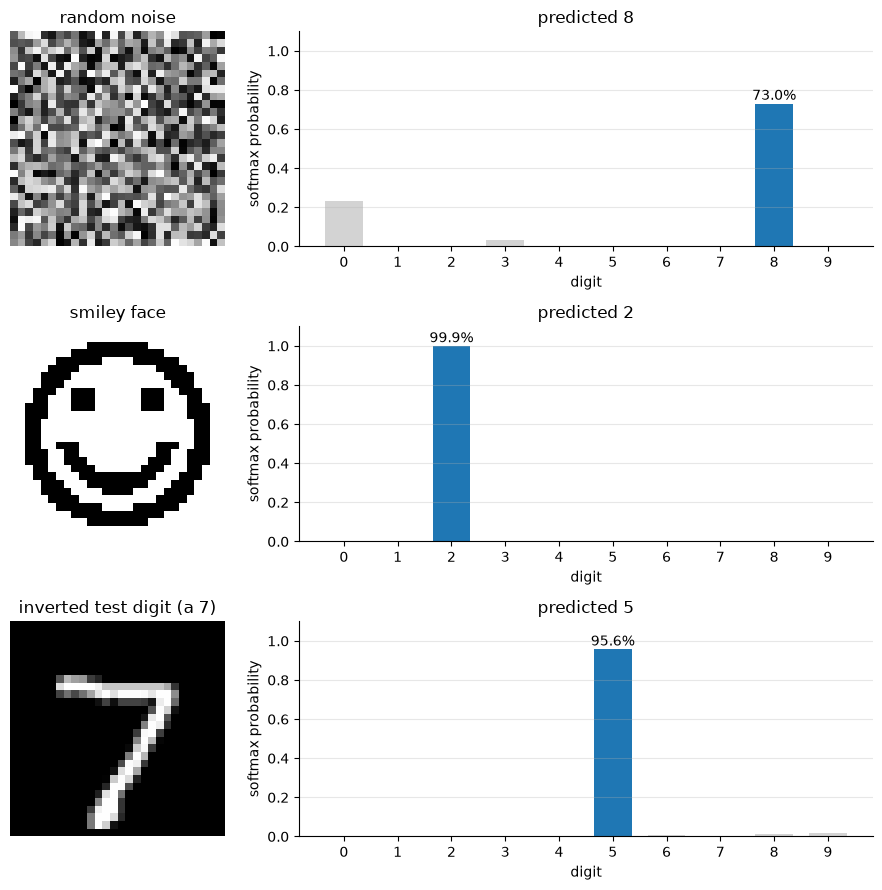

In [7]:
probe_network = Network.load(OVERTRAINED_MODEL_PATH)
print(f"loaded {OVERTRAINED_MODEL_PATH.relative_to(REPO_ROOT).as_posix()}: {[layer.weights.shape for layer in probe_network.layers]}")

rows, cols = np.mgrid[:IMAGE_SIZE, :IMAGE_SIZE]
center = (IMAGE_SIZE - 1) / 2
distance_from_center = np.hypot(rows - center, cols - center)


def smiley_face():
    face = np.abs(distance_from_center - 11) < 1.2
    eyes = (np.hypot(rows - 9, cols - 9) < 2) | (np.hypot(rows - 9, cols - 18) < 2)
    mouth = (np.abs(distance_from_center - 6.5) < 1.2) & (rows > center + 1)
    return (face | eyes | mouth).astype(float)


PROBE_INPUTS = {
    "random noise": np.random.default_rng(0).random((IMAGE_SIZE, IMAGE_SIZE)),
    "smiley face": smiley_face(),
    f"inverted test digit (a {test_labels[0]})": 1 - test_images[0] / 255.0,
}

fig, axes = plt.subplots(len(PROBE_INPUTS), 2, figsize=(9, 3 * len(PROBE_INPUTS)), gridspec_kw={"width_ratios": [1, 2.5]})
for (name, image), (image_ax, bar_ax) in zip(PROBE_INPUTS.items(), axes):
    probabilities = probe_network.forward(image.reshape(1, -1))[0]
    predicted = int(np.argmax(probabilities))
    runner_up = int(np.argsort(probabilities)[-2])

    image_ax.imshow(image, cmap="gray_r", vmin=0, vmax=1)
    image_ax.set_title(name)
    image_ax.axis("off")

    # the predicted digit is the one accent bar; every other digit stays grey
    colors = ["tab:blue" if digit == predicted else "lightgray" for digit in range(NUM_CLASSES)]
    bar_ax.bar(range(NUM_CLASSES), probabilities, color=colors, width=0.7)
    bar_ax.text(predicted, probabilities[predicted] + 0.02, f"{probabilities[predicted]:.1%}", ha="center")
    bar_ax.set_xticks(range(NUM_CLASSES))
    bar_ax.set_ylim(0, 1.1)
    bar_ax.set_xlabel("digit")
    bar_ax.set_ylabel("softmax probability")
    bar_ax.set_title(f"predicted {predicted}")
    bar_ax.grid(axis="y", alpha=0.3)
    bar_ax.spines[["top", "right"]].set_visible(False)

    print(
        f"{name:<26} -> {predicted} with {probabilities[predicted]:.2%} "
        f"(runner-up {runner_up} with {probabilities[runner_up]:.2%}, probabilities sum to {probabilities.sum():.3f})"
    )

fig.tight_layout()
plt.show()

### Observations

| Input | Predicted | Confidence | Runner-up |
|---|---|---|---|
| Random noise | 8 | 73.00% | 0 (23.24%) |
| Smiley face | 2 | 99.87% | 3 (0.09%) |
| Inverted 7 | 5 | 95.62% | 9 (2.04%) |

None of the three is treated as uncertain. The network was never shown anything but digits, so
it has only learned *which digit* an image looks most like, not *whether* it looks like a digit:

1. **Random noise** puts ink everywhere, and 8 and 0 — the digits whose strokes cover the most of
   the image — take 96% of the probability between them.
2. **The smiley face** gets the most confident answer of all (99.87%), even though it is arguably the
   least digit-like input. Whatever pixels the network matched, nothing in its output hints that the
   input is unusual.
3. **The inverted 7** contains exactly the same shape as a real test digit, yet the network calls it
   a 5 with 95.62% confidence. The network did not learn the shape of a 7; it learned which *pixel
   positions* are dark for a 7, and inverting the image turns almost every pixel dark.

Softmax confidence therefore says nothing about whether an input belongs to the training
distribution. Rejecting non-digits would need something more — for example an extra "not a digit"
class trained on such inputs, or a confidence threshold calibrated on held-out data.